# Exp8.0.3 — Phase-aware hierarchical L1/L2 count readout

Aggregation-only notebook. It reads finalizer outputs and does not train models or refit probes. Primary comparison: `l1_fixed250_l2_whole_count` vs the parameter-matched `l1_capacity_no_phase_l2_whole_count` control. All Exp8.0.3 native methods use count-form CE; Exp8.0.2 remains the external valid-mean reference.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / 'scripts').exists():
    ROOT = ROOT.parent
ART = ROOT / 'notebooks' / 'artifacts' / 'experiment_8_0_3_phase_aware_hierarchical_readout' / 'phase_aware_hierarchical_readout_v2'
manifest = json.loads((ART / 'manifest.json').read_text())
method = pd.read_csv(ART / 'method_summary.csv')
method_runs = pd.read_csv(ART / 'method_runs.csv')
probe = pd.read_csv(ART / 'probe_summary.csv')
fusion = pd.read_csv(ART / 'fusion_gain_summary.csv')
overlap = pd.read_csv(ART / 'correctness_overlap_summary.csv')
heads = pd.read_csv(ART / 'trained_head_summary.csv')
paired = pd.read_csv(ART / 'paired_delta_summary.csv')
phase = pd.read_csv(ART / 'phase_structure_summary.csv')
history = pd.read_csv(ART / 'history_runs.csv')
manifest

{'architecture': '234x234',
 'architecture_shifts': [[2, 3, 4], [2, 3, 4]],
 'capacity_control_scale': '1/sqrt(n_bins)',
 'counts': {'methods': 4, 'parallel_runs': 12, 'seeds': 3},
 'experiment_id': 'experiment_8_0_3_phase_aware_hierarchical_readout',
 'methods': ['l2_only_count',
  'l1_l2_timeshared_count',
  'l1_fixed250_l2_whole_count',
  'l1_capacity_no_phase_l2_whole_count'],
 'output_lif': {'alpha': 0.0, 'beta': 0.5, 'cap': 1, 'threshold': 0.5},
 'primary_comparison': 'l1_fixed250_l2_whole_count - l1_capacity_no_phase_l2_whole_count',
 'protocol_version': 'phase_aware_hierarchical_readout_v2',
 'seeds': [11, 23, 37],
 'target_posthoc_probe': 'l1fixed250_l2whole',
 'training': 'end-to-end CE on the exact count-form accumulated class evidence; no valid-length division'}

## Native count accumulator and same-evidence output-LIF performance

In [2]:
cols = [
    'method', 'native_test_ba_mean', 'native_test_ba_std',
    'lif_test_ba_mean', 'lif_test_ba_std', 'lif_penalty_mean',
    'accumulator_equivalence_error_mean', 'parameter_count_mean',
    'l1_score_rms_fraction_mean',
]
display(method[cols].sort_values('native_test_ba_mean', ascending=False))

,method,native_test_ba_mean,native_test_ba_std,lif_test_ba_mean,lif_test_ba_std,lif_penalty_mean,accumulator_equivalence_error_mean,parameter_count_mean,l1_score_rms_fraction_mean
2,l1_fixed250_l2_whole_count,0.485277,0.051657,0.253515,0.029005,0.231763,0.000011,46336.0,0.615864
1,l1_l2_timeshared_count,0.467710,0.026418,0.342782,0.052768,0.124928,0.000015,23296.0,0.308962
3,l1_capacity_no_phase_l2_whole_count,0.432146,0.036687,0.300118,0.055193,0.132028,0.000009,46336.0,0.515819
0,l2_only_count,0.378149,0.016204,0.289926,0.010950,0.088223,0.000015,21760.0,0.000000


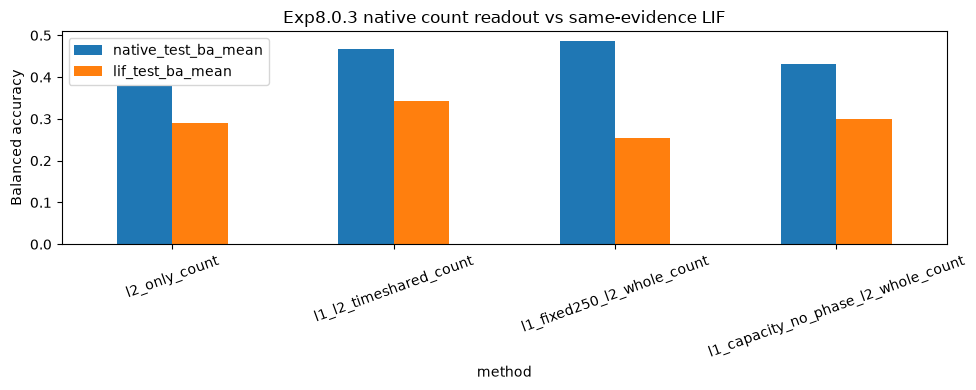

In [3]:
plot = method.set_index('method')[['native_test_ba_mean', 'lif_test_ba_mean']]
ax = plot.plot(kind='bar', figsize=(10, 4), rot=20)
ax.set_ylabel('Balanced accuracy')
ax.set_title('Exp8.0.3 native count readout vs same-evidence LIF')
plt.tight_layout()

## Paired seed deltas — primary mechanism test

In [4]:
display(paired)
display(method_runs.pivot(index='seed', columns='method', values='native_test_ba'))

,comparison,native_test_ba_delta_mean,native_test_ba_delta_std,lif_test_ba_delta_mean,lif_test_ba_delta_std,target_probe_test_ba_delta_mean,target_probe_test_ba_delta_std
0,phase_vs_capacity,0.053131,0.018270,-0.046603,0.083717,0.063996,0.023628
1,phase_vs_timeshared,0.017568,0.074874,-0.089267,0.081508,0.025696,0.020177
2,timeshared_vs_l2,0.089561,0.031968,0.052856,0.051221,0.095875,0.039206


method,l1_capacity_no_phase_l2_whole_count,l1_fixed250_l2_whole_count,l1_l2_timeshared_count,l2_only_count
seed,,,,
11,0.458777,0.532769,0.437231,0.378715
23,0.447363,0.492786,0.481851,0.394062
37,0.390299,0.430277,0.484047,0.361669


## Frozen representation probes

In [5]:
focus = probe[probe.feature.isin([
    'l1_fixed250', 'l2_whole', 'l1fixed250_l2whole',
    'l2_fixed250', 'l1_l2_fixed250'
])][['method', 'feature', 'test_ba_mean', 'test_ba_std', 'train_test_gap_mean']]
display(focus.sort_values(['feature', 'test_ba_mean'], ascending=[True, False]))

,method,feature,test_ba_mean,test_ba_std,train_test_gap_mean
16,l1_fixed250_l2_whole_count,l1_fixed250,0.506436,0.019418,0.482576
8,l1_l2_timeshared_count,l1_fixed250,0.501126,0.049111,0.457410
24,l1_capacity_no_phase_l2_whole_count,l1_fixed250,0.477416,0.035392,0.481638
0,l2_only_count,l1_fixed250,0.439242,0.031406,0.510226
17,l1_fixed250_l2_whole_count,l1_l2_fixed250,0.569990,0.023328,0.404782
9,l1_l2_timeshared_count,l1_l2_fixed250,0.484417,0.031487,0.496131
25,l1_capacity_no_phase_l2_whole_count,l1_l2_fixed250,0.467321,0.022103,0.510795
1,l2_only_count,l1_l2_fixed250,0.450678,0.004095,0.446882
20,l1_fixed250_l2_whole_count,l1fixed250_l2whole,0.547237,0.024390,0.410471
12,l1_l2_timeshared_count,l1fixed250_l2whole,0.521541,0.031278,0.413648


## Does the large L1 bank actually learn phase-specific weights?

In [6]:
display(phase[['method', 'mean_pairwise_cosine_mean', 'mean_adjacent_cosine_mean', 'between_bin_weight_rms_mean']])
display(heads)

,method,mean_pairwise_cosine_mean,mean_adjacent_cosine_mean,between_bin_weight_rms_mean
0,l1_fixed250_l2_whole_count,0.105737,0.247370,0.033258
1,l1_capacity_no_phase_l2_whole_count,0.909799,0.909931,0.012343


,method,head,coef_fro_norm_mean,coef_fro_norm_std,coef_rms_mean,coef_rms_std,coef_norm_fraction_mean,coef_norm_fraction_std
0,l2_only_count,l2,3.228688,0.066883,0.082382,0.001707,1.000000,0.000000
1,l1_l2_timeshared_count,l2,2.849105,0.026575,0.072696,0.000678,0.487190,0.003257
2,l1_l2_timeshared_count,l1_timeshared,2.998860,0.012151,0.076517,0.000310,0.512810,0.003257
3,l1_fixed250_l2_whole_count,l2,2.302892,0.145118,0.058759,0.003703,0.288262,0.027058
4,l1_fixed250_l2_whole_count,l1_large_bank,5.751240,0.981993,0.036686,0.006264,0.711738,0.027058
5,l1_capacity_no_phase_l2_whole_count,l2,2.641155,0.099082,0.067390,0.002528,0.283479,0.010975
6,l1_capacity_no_phase_l2_whole_count,l1_large_bank,6.685730,0.447077,0.042647,0.002852,0.716521,0.010975


## Complementarity and post-hoc fusion diagnostics

In [7]:
display(fusion)
display(overlap[(overlap.split == 'test') & (overlap.aggregation.isin(['fixed250', 'whole']))])

,method,fixed250_fusion_gain_over_best_single_mean,fixed250_fusion_gain_over_best_single_std,l1whole_l2fixed250_gain_over_l2fixed250_mean,l1whole_l2fixed250_gain_over_l2fixed250_std,reverse_mixed_gain_over_best_component_mean,reverse_mixed_gain_over_best_component_std,whole_fusion_gain_over_best_single_mean,whole_fusion_gain_over_best_single_std
0,l2_only_count,-0.008119,0.003319,-0.002162,0.012821,-0.013576,0.004224,0.012611,0.031068
1,l1_l2_timeshared_count,-0.031028,0.033975,-0.008324,0.035853,0.011727,0.008604,0.016556,0.049897
2,l1_fixed250_l2_whole_count,0.020374,0.019943,0.025139,0.008480,0.040800,0.043178,0.000338,0.031037
3,l1_capacity_no_phase_l2_whole_count,-0.010094,0.019628,0.011914,0.074479,0.005825,0.022881,-0.004154,0.013363


,method,aggregation,split,both_correct_mean,both_correct_std,l1_only_correct_mean,l1_only_correct_std,l2_only_correct_mean,l2_only_correct_std,both_wrong_mean,both_wrong_std,prediction_disagreement_mean,prediction_disagreement_std,oracle_union_accuracy_mean,oracle_union_accuracy_std
0,l2_only_count,fixed250,test,0.324201,0.030885,0.116438,0.018122,0.127854,0.044035,0.431507,0.011863,0.452055,0.059711,0.568493,0.011863
3,l2_only_count,whole,test,0.262557,0.048108,0.127854,0.024054,0.141553,0.037723,0.468037,0.025931,0.490868,0.075446,0.531963,0.025931
6,l1_l2_timeshared_count,fixed250,test,0.420091,0.041850,0.091324,0.014258,0.100457,0.024054,0.388128,0.030885,0.381279,0.014258,0.611872,0.030885
9,l1_l2_timeshared_count,whole,test,0.324201,0.022017,0.116438,0.041663,0.150685,0.024696,0.408676,0.027681,0.440639,0.070296,0.591324,0.027681
12,l1_fixed250_l2_whole_count,fixed250,test,0.431507,0.047945,0.086758,0.037723,0.130137,0.041096,0.351598,0.020925,0.390411,0.085548,0.648402,0.020925
15,l1_fixed250_l2_whole_count,whole,test,0.305936,0.081715,0.162100,0.041286,0.148402,0.030885,0.383562,0.020548,0.520548,0.085548,0.616438,0.020548
18,l1_capacity_no_phase_l2_whole_count,fixed250,test,0.335616,0.075342,0.148402,0.041850,0.111872,0.014258,0.404110,0.029855,0.456621,0.119879,0.595890,0.029855
21,l1_capacity_no_phase_l2_whole_count,whole,test,0.319635,0.048593,0.152968,0.015818,0.116438,0.006849,0.410959,0.027397,0.468037,0.041286,0.589041,0.027397


## Training curves — method-level view only

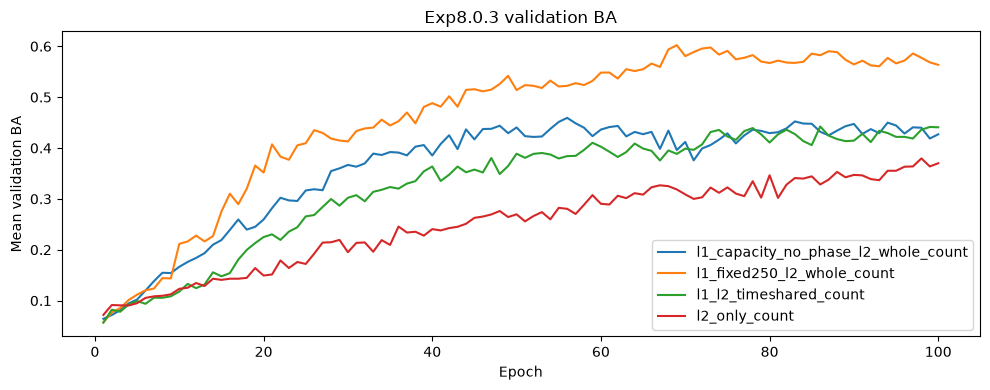

In [8]:
curve = history.groupby(['method', 'epoch'], as_index=False)[['train_ba', 'val_ba', 'train_loss', 'val_loss']].mean()
fig, ax = plt.subplots(figsize=(10, 4))
for name, frame in curve.groupby('method'):
    ax.plot(frame.epoch, frame.val_ba, label=name)
ax.set_xlabel('Epoch')
ax.set_ylabel('Mean validation BA')
ax.set_title('Exp8.0.3 validation BA')
ax.legend()
plt.tight_layout()